In [3]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# Helper function for visualization.
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt


def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()


def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    plt.show()

2.6.0+cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 33.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 3.8 MB/s eta 0:00:00


# 这是一个开始：动手实践图神经网络（Graph Neural Networks）

近年来，图上的深度学习已经成为深度学习领域最热门的研究方向之一。  
**图神经网络（GNNs）** 的目标是将传统深度学习的概念推广到**非规则结构的数据**（与图像或文本等规则结构数据相对），并使神经网络能够对**对象及其关系进行推理**。

这一目标通过一种简单的 **神经消息传递机制（neural message passing scheme）** 来实现。在这种机制下，图 $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ 中所有节点 $v \in \mathcal{V}$ 的节点特征 $\mathbf{x}_v^{(\ell)}$ 会通过从其邻居节点 $\mathcal{N}(v)$ 聚合局部信息来迭代更新：

$$
\mathbf{x}_v^{(\ell + 1)} = f^{(\ell + 1)}_{\theta} \left( \mathbf{x}_v^{(\ell)}, \left\{ \mathbf{x}_w^{(\ell)} : w \in \mathcal{N}(v) \right\} \right)
$$

本教程将通过基于 **[PyTorch Geometric (PyG) 库](https://github.com/rusty1s/pytorch_geometric)** 的实践操作，为你介绍图上深度学习的一些基本概念。  
PyTorch Geometric 是流行的深度学习框架 [PyTorch](https://pytorch.org/) 的一个扩展库，它包含多种方法和工具，能够简化图神经网络的实现过程。

接下来，我们将参考 [Kipf 等人（2017）](https://arxiv.org/abs/1609.02907) 的工作，深入了解图神经网络的世界。我们会从一个简单的图结构实例开始，即著名的 [**Zachary 的空手道俱乐部网络（Zachary's karate club network）**](https://en.wikipedia.org/wiki/Zachary%27s_karate_club)。  
该图描述了一个包含 34 名成员的空手道俱乐部的社交网络，并记录了成员之间在俱乐部外的互动关系。我们感兴趣的是识别这些互动关系中自然形成的社群（社区）。

借助 [`torch_geometric.datasets`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets) 子包，PyTorch Geometric 为我们提供了便捷的方式来访问该数据集。

In [4]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


在初始化 [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) 数据集后，我们可以先查看它的一些属性。

例如，我们可以看到该数据集仅包含 **一个图**，并且图中每个节点都被分配了一个 **34维的特征向量**（该向量可以唯一描述空手道俱乐部的成员）。

此外，该图包含 **4 个类别**，表示每个节点所属的社群（community）。

接下来，我们将更详细地查看该图的底层结构：

In [5]:
data = dataset[0]  # Get the first graph object.

print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


在 PyTorch Geometric 中，每个图都被表示为一个 [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) 对象，它包含了描述图结构所需的所有信息。  
我们可以随时使用 `print(data)` 来打印该对象，从而快速查看它的属性及其形状摘要：
```
Data(edge_index=[2, 156], x=[34, 34], y=[34], train_mask=[34])
```
从中可以看到，这个 `data` 对象包含 4 个主要属性：

1. `edge_index`：表示图的**连接关系（Graph Connectivity）**，是一个二维张量，包含每条边的源节点和目标节点索引；
2. `x`：表示**节点特征（Node Features）**，在这个例子中，每个节点被分配了一个 34 维的特征向量；
3. `y`：表示**节点标签（Node Labels）**，即每个节点所属的类别；
4. `train_mask`：一个布尔向量，指示哪些节点的类别是已知的（用于训练）。在这个数据集中，我们只知道 4 个节点的真实标签（每个社群各一个），任务是推断其余节点的社群归属。

此外，`data` 对象还提供了一些**实用函数（utility functions）**，可以帮助我们推断图的一些基本性质，例如：

- 图中是否存在孤立节点（即没有与其他节点相连的边）；
- 图中是否存在自环（self-loops），即是否存在形如 $(v, v) \in \mathcal{E}$ 的边；
- 图是否是无向图（即每条边 $(v, w)$ 是否也有对应的反向边 $(w, v)$）。

接下来，让我们更详细地查看 `edge_index` 属性。

In [6]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

edge_index = data.edge_index
print(edge_index.t())

<IPython.core.display.Javascript object>

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

通过打印 `edge_index`，我们可以了解 PyG 在内部是如何表示图的连接关系的。  
对于每一条边，`edge_index` 保存了两个节点索引的元组，其中第一个值表示边的**源节点**的索引，第二个值表示边的**目标节点**的索引。

这种表示方式被称为 **COO 格式（坐标格式，Coordinate Format）**，在表示稀疏矩阵时被广泛使用。  
与其使用一个稠密的邻接矩阵表示法 $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$ 不同，PyG 使用稀疏表示法，即**仅存储邻接矩阵中非零元素的位置和值**。

需要注意的是，PyG 并不区分**有向图**和**无向图**，而是将无向图看作是特殊的有向图，其中每一条边 $(v, w)$ 都有对应的反向边 $(w, v)$ 出现在 `edge_index` 中。

我们还可以将图转换为 `networkx` 库的格式来进行可视化。  
`networkx` 除了支持各种图结构操作外，还提供了功能强大的可视化工具：

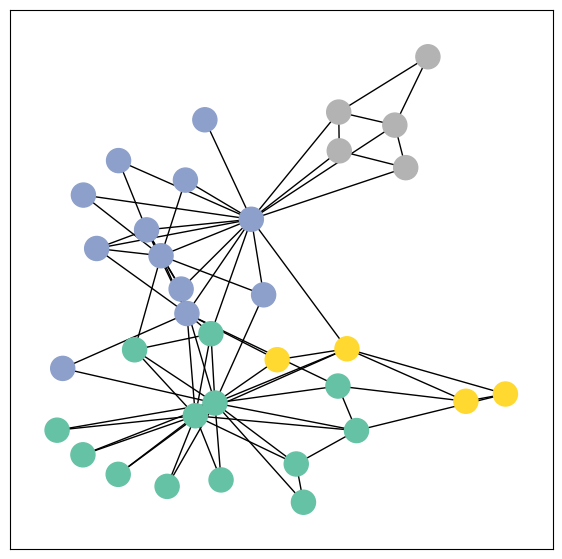

In [8]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

## 实现图神经网络（Graph Neural Networks）

在了解了 PyG 的数据处理方式之后，接下来是我实现的第一个图神经网络！

为此，我们将使用最简单的 GNN 算子之一——**GCN 层**（来自 [Kipf 等人, 2017](https://arxiv.org/abs/1609.02907)），其定义如下：

$$
\mathbf{x}_v^{(\ell + 1)} = \mathbf{W}^{(\ell + 1)} \sum_{w \in \mathcal{N}(v) \, \cup \, \{ v \}} \frac{1}{c_{w,v}} \cdot \mathbf{x}_w^{(\ell)}
$$

其中，$\mathbf{W}^{(\ell + 1)}$ 表示一个可训练的权重矩阵，形状为 `[num_output_features, num_input_features]`，而 $c_{w,v}$ 是边的一个固定归一化系数。

在 PyG 中，这一层通过 [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv) 进行实现，只需传入节点特征 `x` 和 COO 格式的图连接关系 `edge_index` 即可执行。

有了这些准备，我们就可以通过定义一个继承自 `torch.nn.Module` 的类，来构建一个图神经网络模型：

In [10]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


在这里，我首先在 `__init__` 方法中初始化所有的构建模块，并在 `forward` 方法中定义网络的前向传播流程。

首先定义并堆叠了**三层图卷积层（GCNConv）**，这相当于聚合每个节点 3 跳邻居（即距离节点最多为 3 条边的其他节点）范围内的信息。  
此外，这些 `GCNConv` 层会逐步将节点特征的维度压缩为 $2$，也就是 $34 \rightarrow 4 \rightarrow 4 \rightarrow 2$。  
每一层图卷积后都接入了一个 [tanh 激活函数](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html?highlight=tanh#torch.nn.Tanh) 以引入非线性。

接下来，我使用一个线性变换（[`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear)）作为分类器，将每个节点的最终表示映射到 4 个类别/社群中的一个。

将最终分类器的输出和图神经网络生成的节点表示（node embeddings）一起返回。

最后，通过 `GCN()` 初始化模型，使用 `print(model)` 可以输出模型中使用的所有子模块的摘要信息。

### 嵌入空手道俱乐部网络（Embedding the Karate Club Network）

现在让我们来看一下由图神经网络（GNN）生成的节点嵌入（node embeddings）。

在这里，我将初始的节点特征 `x` 和图的连接信息 `edge_index` 输入到模型中，并对其生成的二维嵌入进行可视化展示。

Embedding shape: [34, 2]


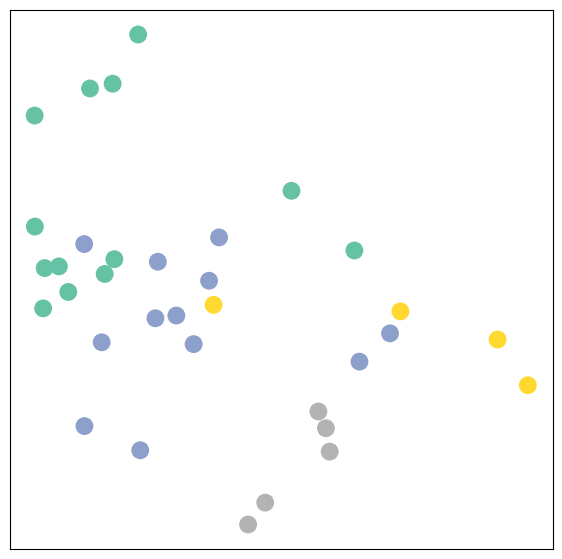

In [11]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize_embedding(h, color=data.y)

令人惊讶的是，即使在还没有对模型进行训练、权重仍然是**完全随机初始化**的情况下，模型生成的节点嵌入就已经非常接近图的社群结构了！  
在嵌入空间中，属于同一颜色（即同一社群）的节点已经自然聚集在一起。

这说明图神经网络具有一种很强的**归纳偏置（inductive bias）**，使得在输入图中彼此接近的节点，在嵌入空间中也具有相似的表示。

---

### 训练空手道俱乐部网络（Training on the Karate Club Network）

那么，能做得更好吗？  
下面是一个训练我们网络参数的例子——将利用图中 4 个已知节点的社群信息（每个社群各选一个）：

由于我们模型中的所有部分都是可微分并且具有参数的，我们可以添加标签信息，对模型进行训练，并观察节点嵌入的变化。

在这里，我们采用的是一种**半监督（semi-supervised）**或**传导式学习（transductive learning）**方法：  
我们只使用每个类别中的一个节点进行训练，但可以利用整个图的结构和特征信息。

训练过程与 PyTorch 中的其他模型非常类似。  
除了定义网络结构外，我们还需要定义一个损失函数（这里使用 [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)），并初始化一个随机梯度优化器（这里使用 [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)）。

之后，我们执行多轮优化，每轮包括一次前向传播和反向传播，以根据损失函数计算模型参数的梯度。  
如果你熟悉 PyTorch，这种训练流程应该非常熟悉。否则，可以参考 PyTorch 官方文档中[关于训练神经网络的入门教程](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer)。

需要注意的是，我的半监督学习过程是通过以下代码实现的：
```
loss = criterion(out[data.train_mask], data.y[data.train_mask])
```
虽然我们为所有节点都计算了嵌入和分类输出，但**在计算损失时只使用了训练集中的节点**。  
这里我们通过 `train_mask` 过滤分类器输出 `out` 和真实标签 `data.y`，从而仅对已标注的节点计算损失。

接下来开始训练，并观察节点嵌入在训练过程中如何逐步演化。

<IPython.core.display.Javascript object>

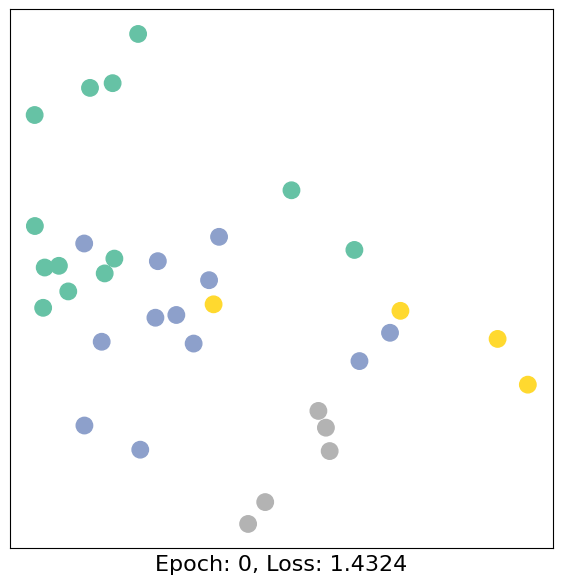

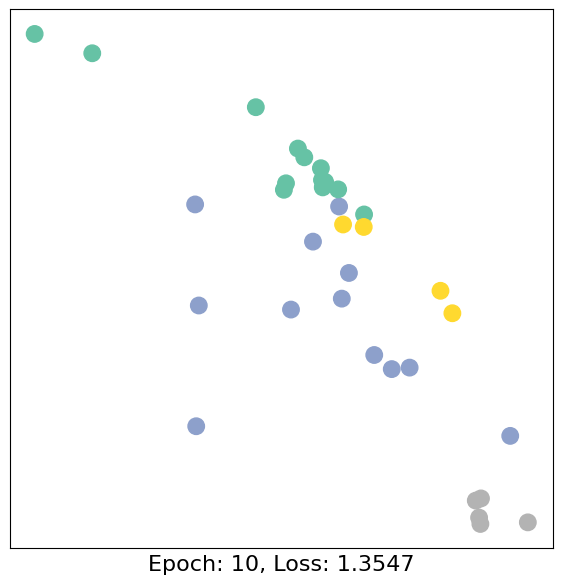

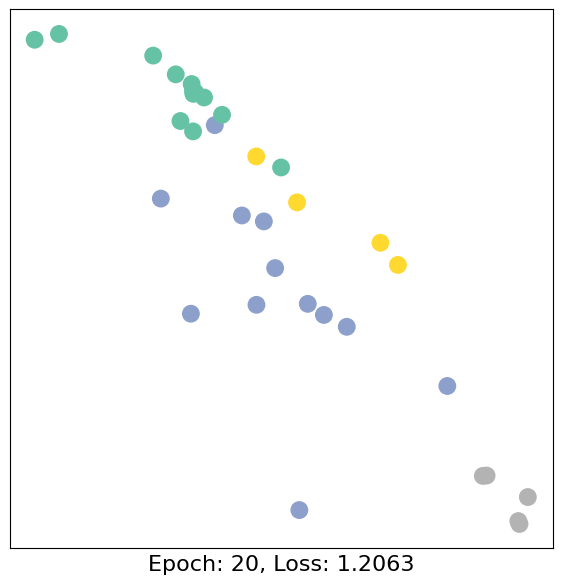

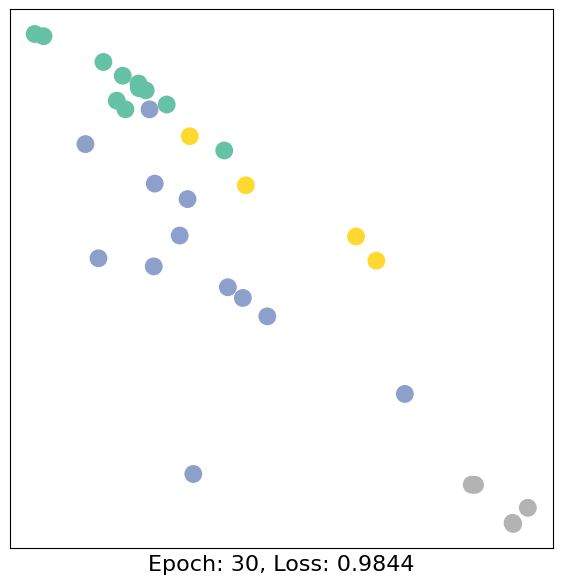

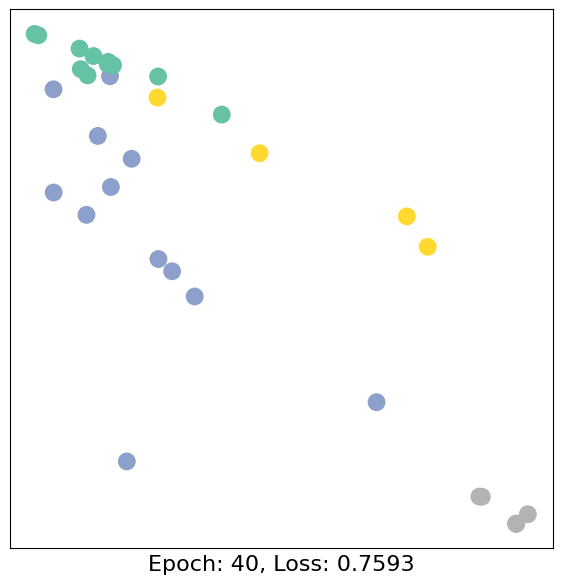

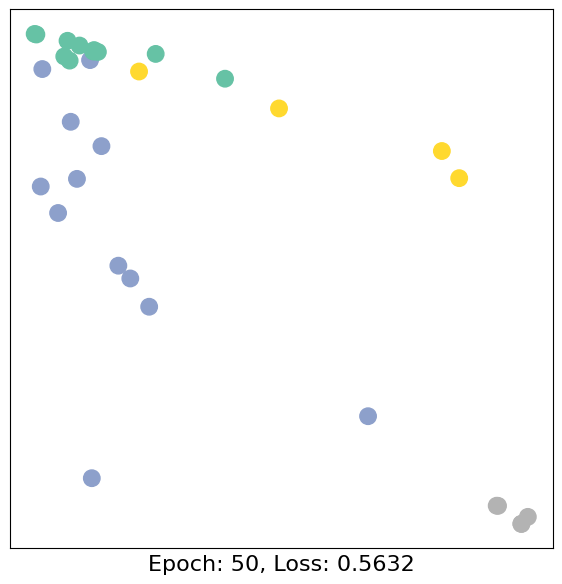

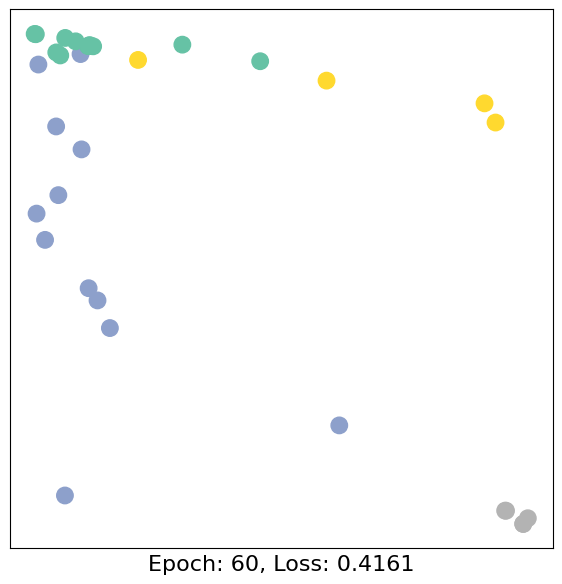

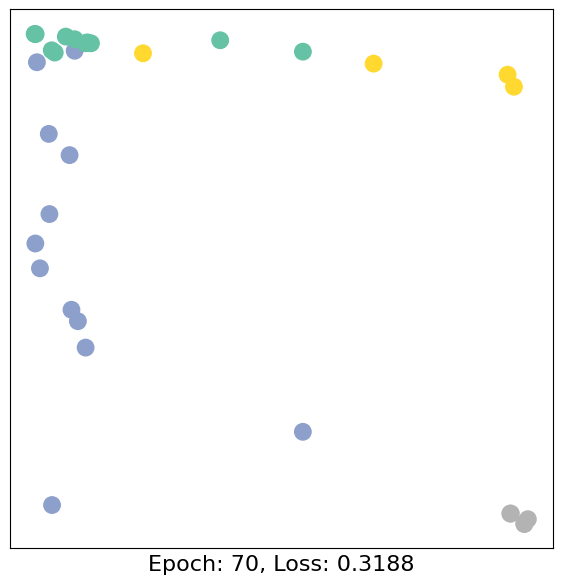

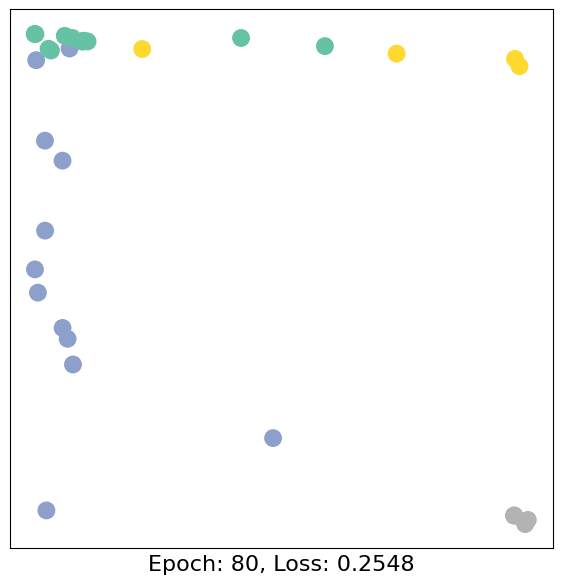

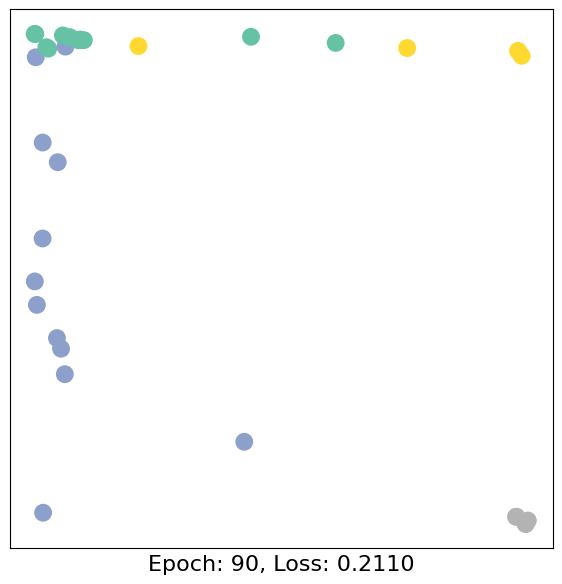

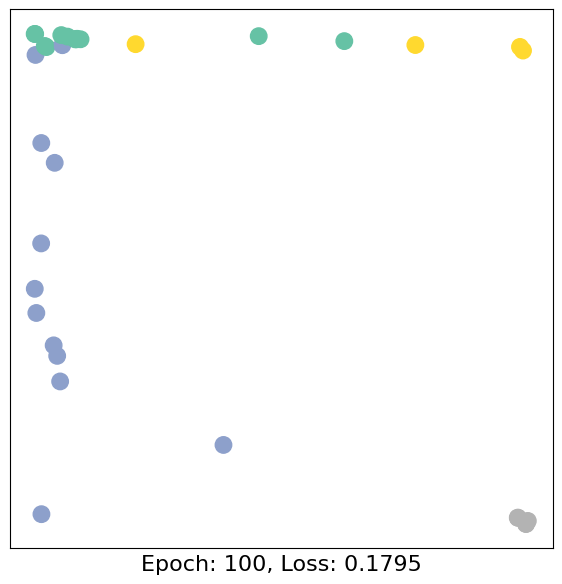

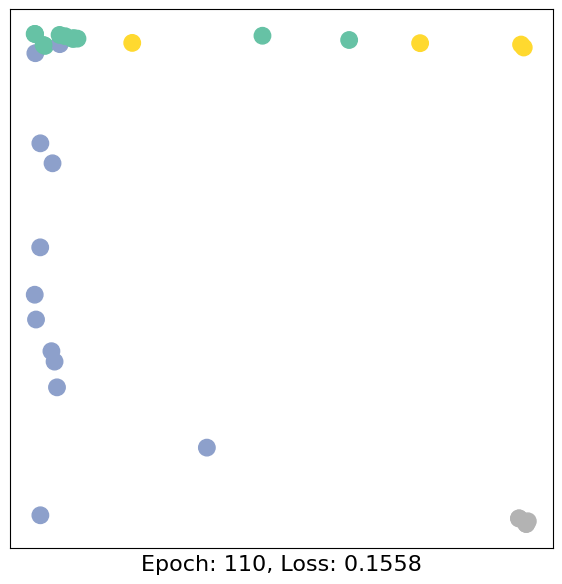

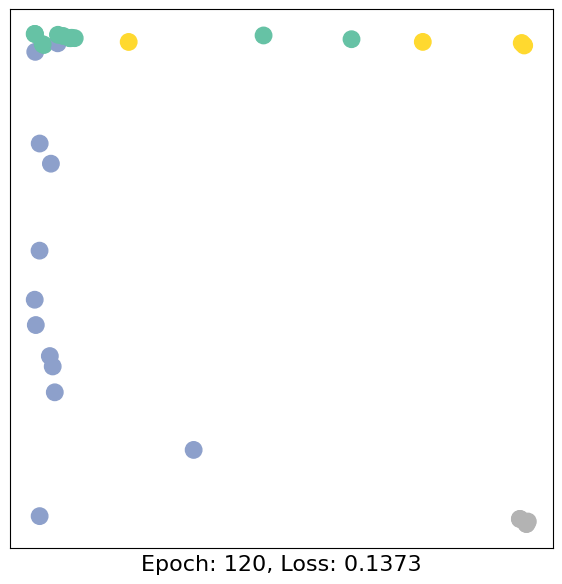

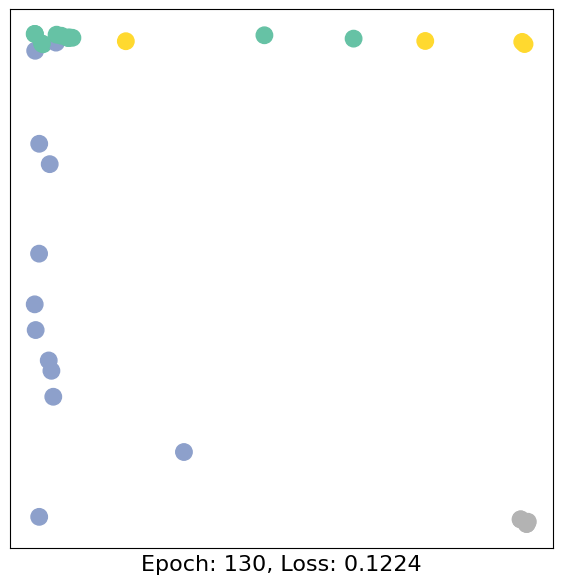

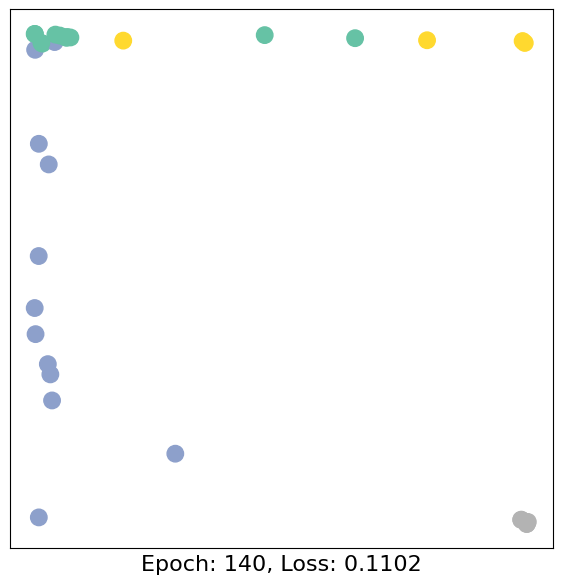

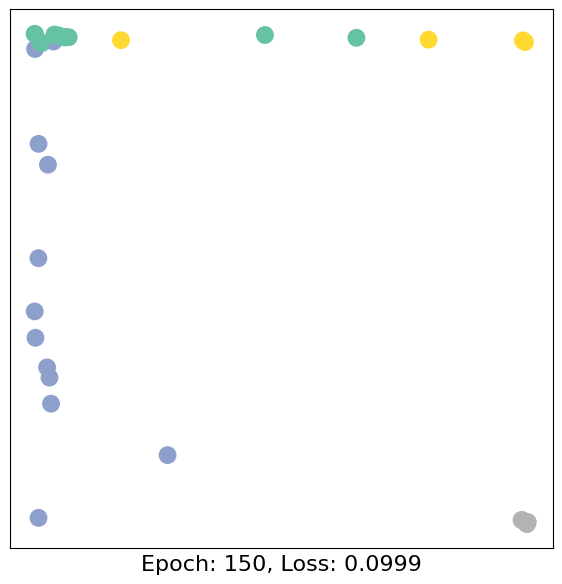

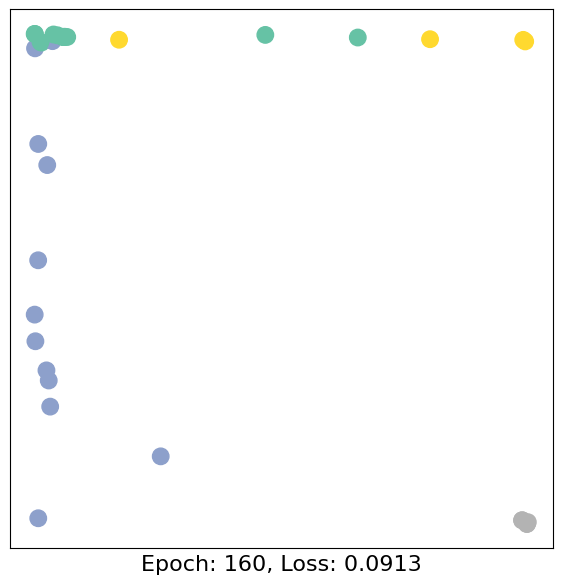

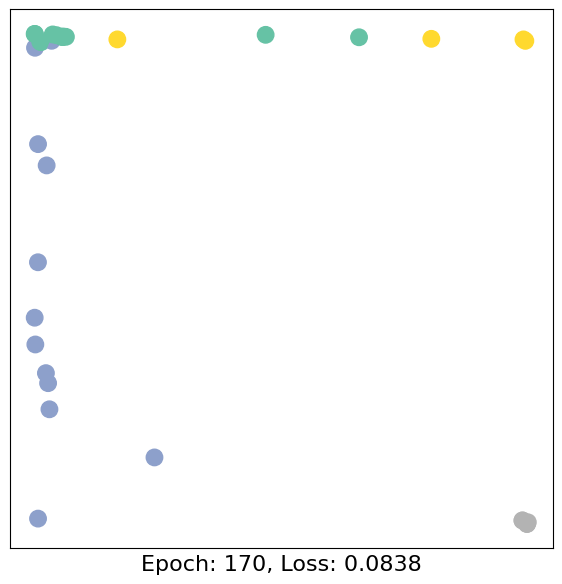

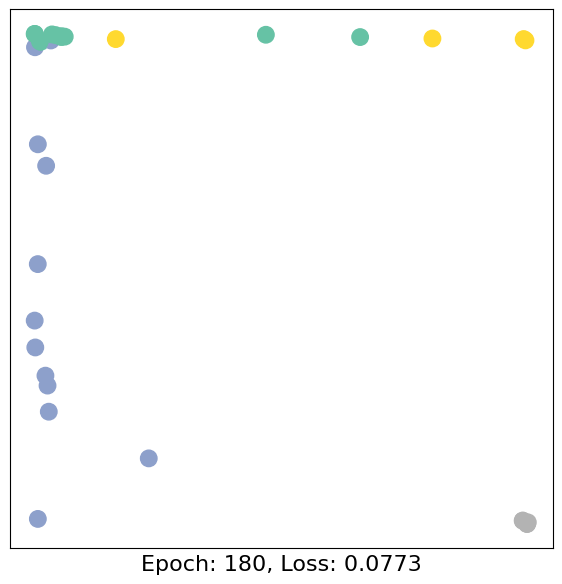

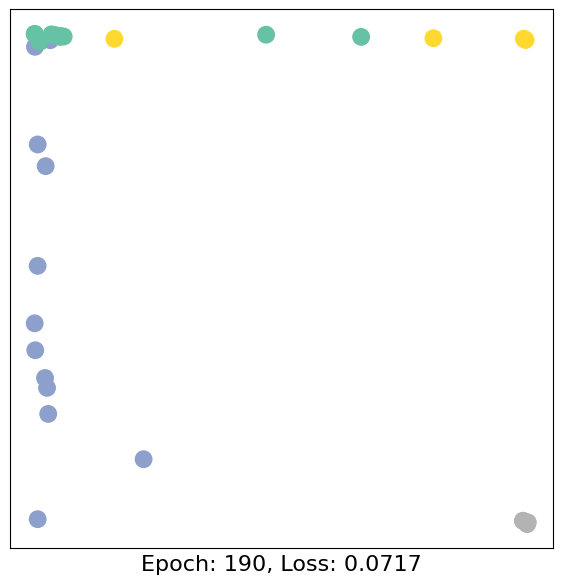

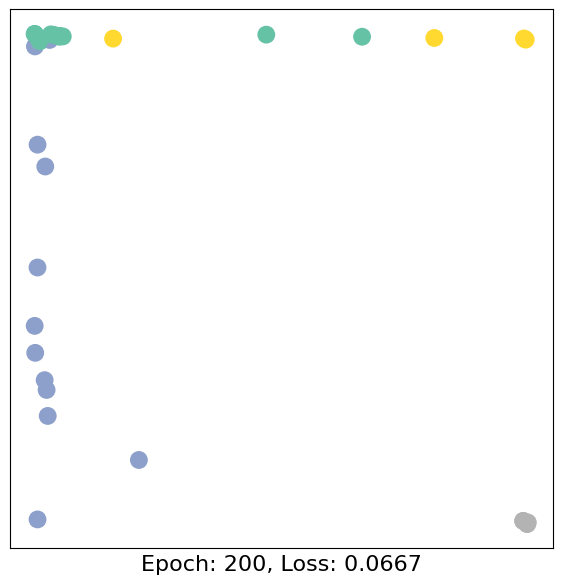

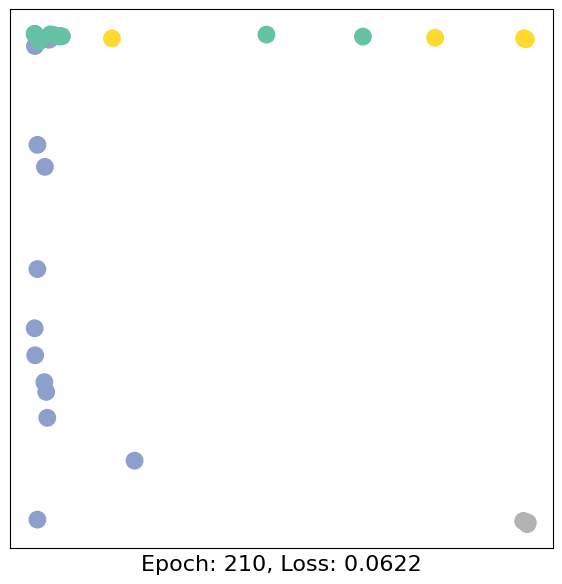

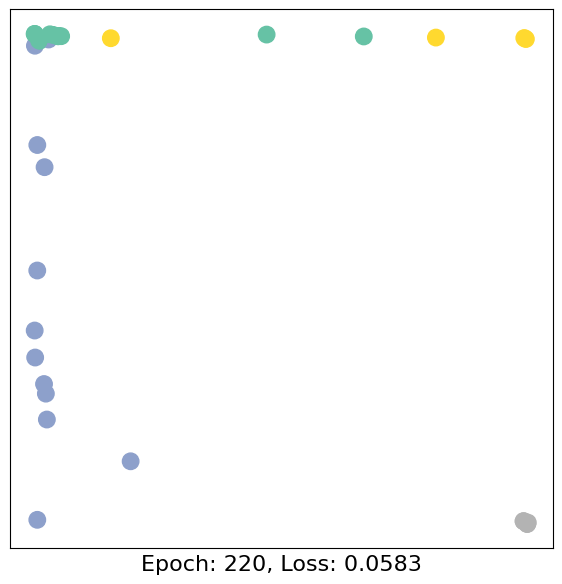

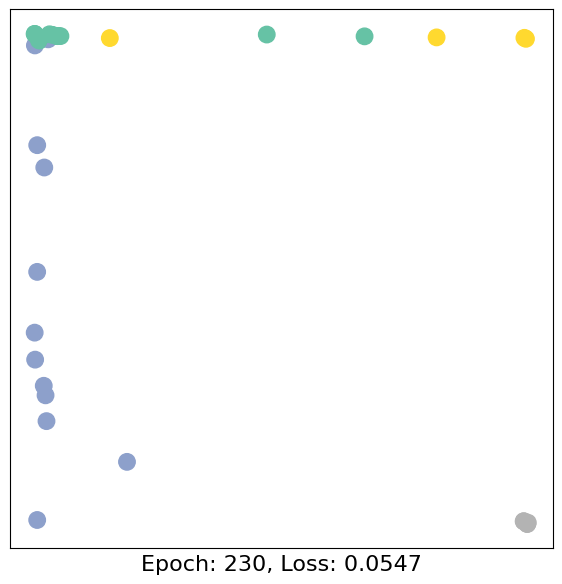

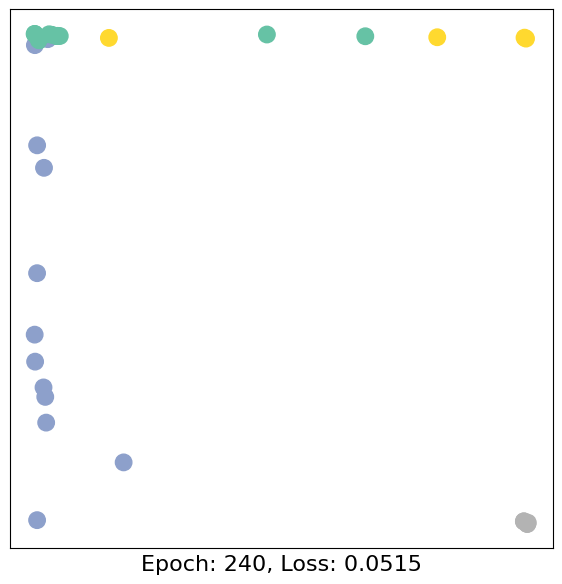

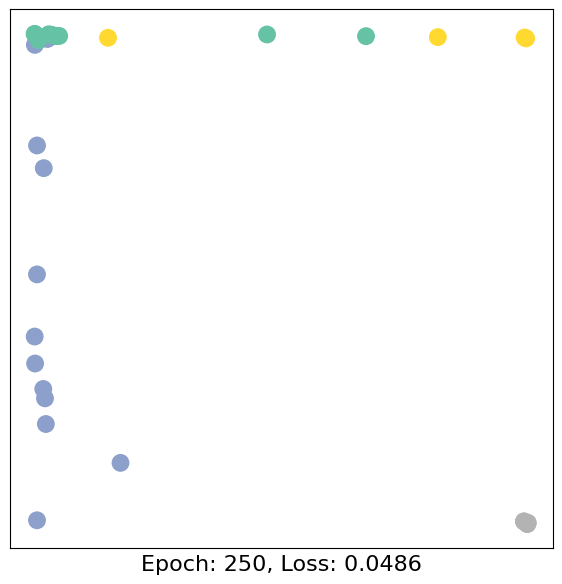

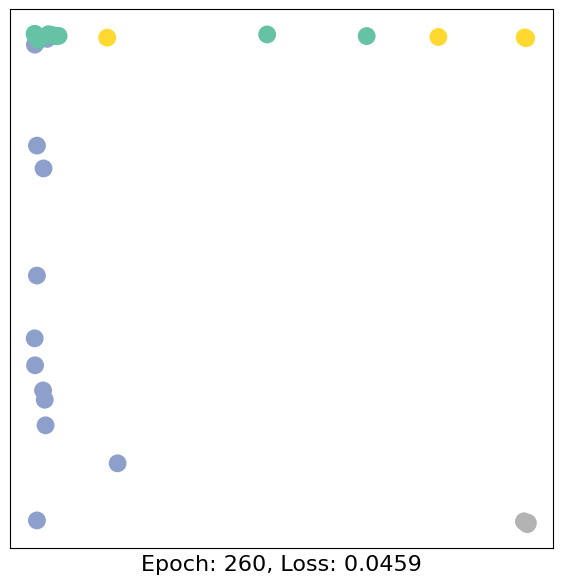

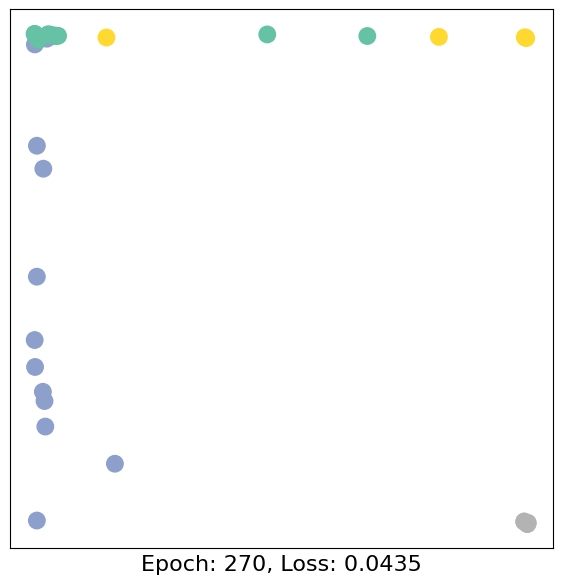

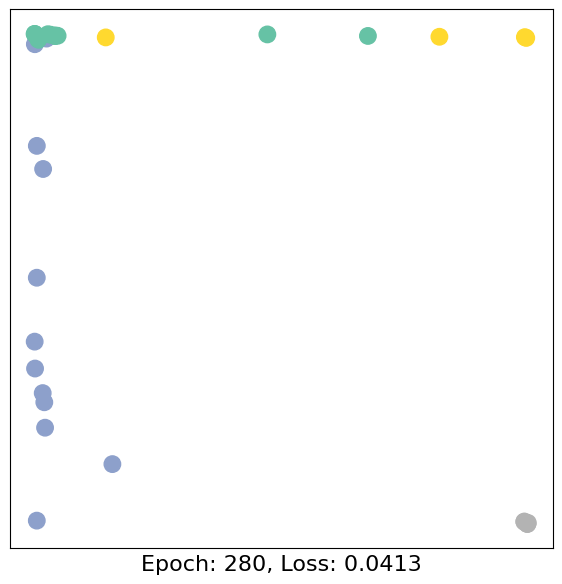

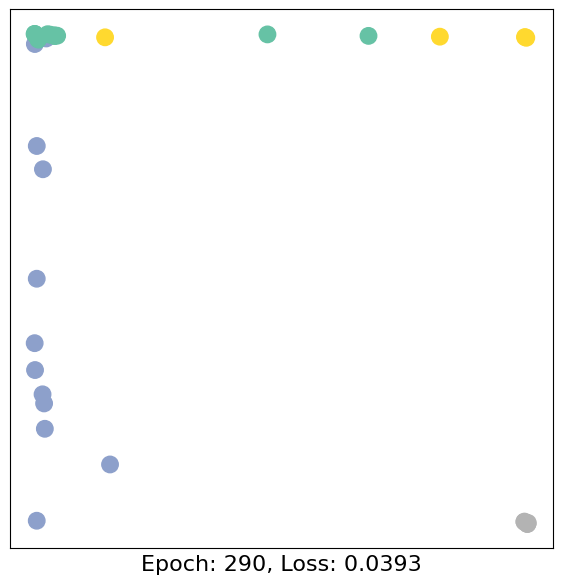

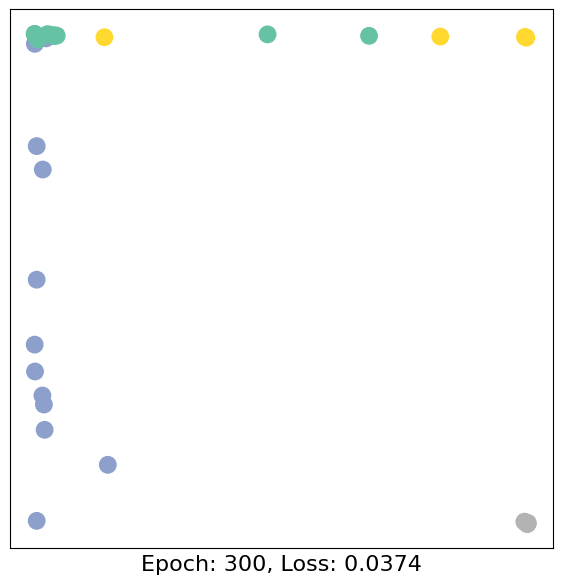

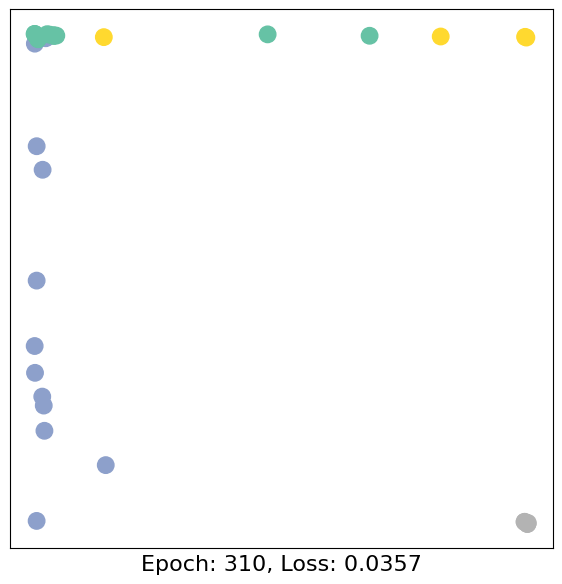

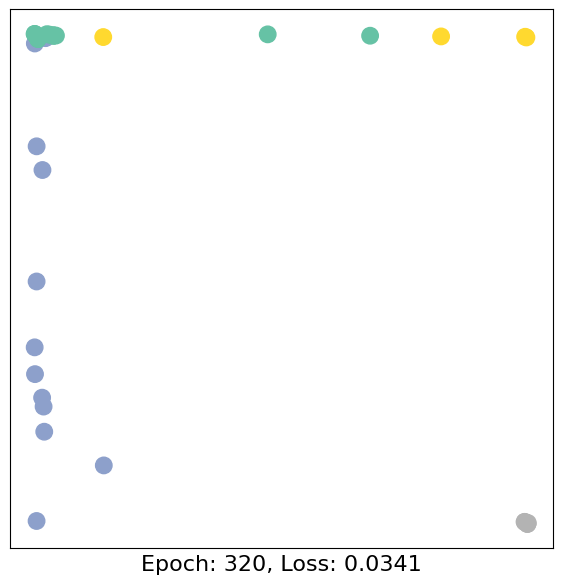

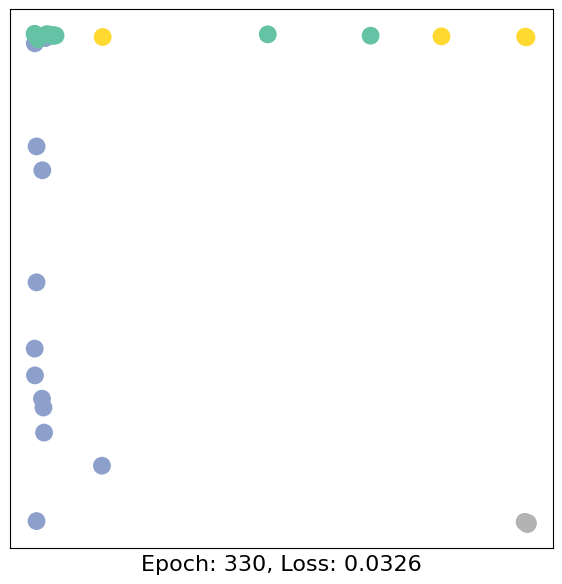

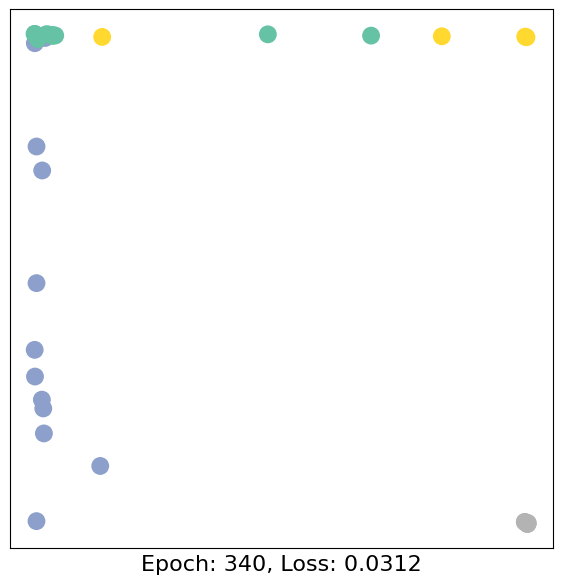

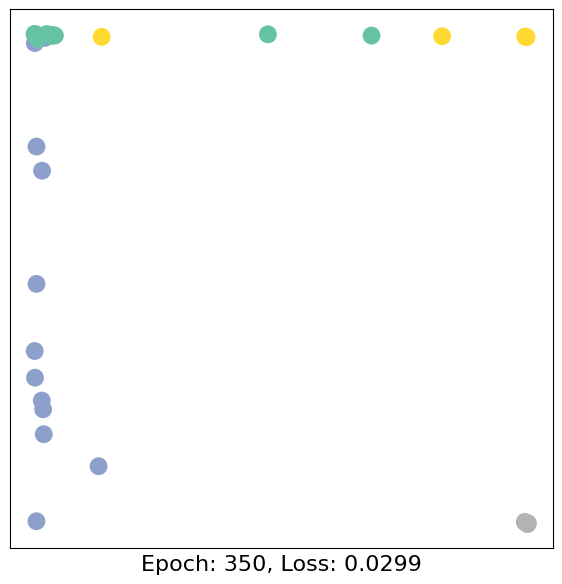

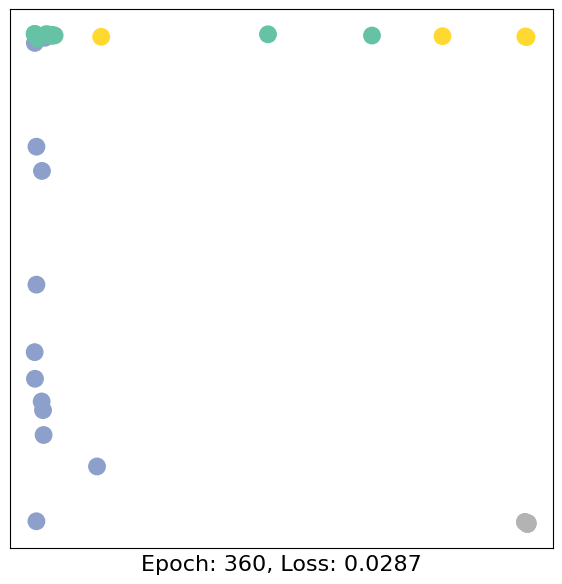

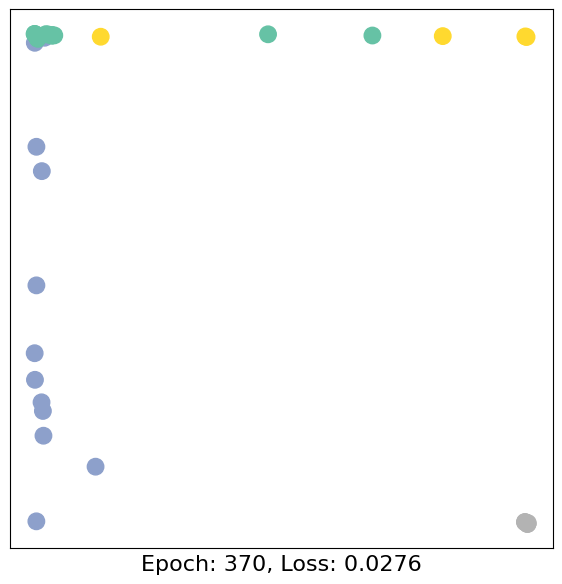

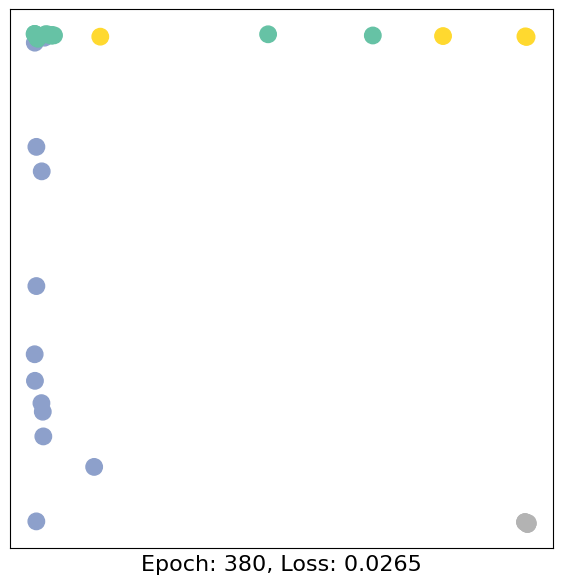

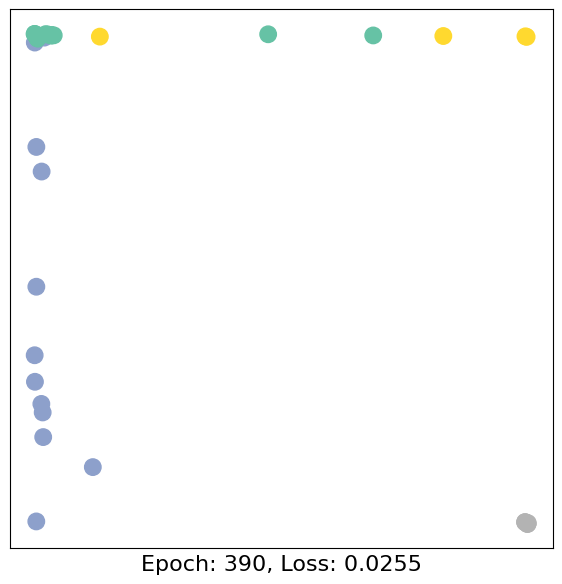

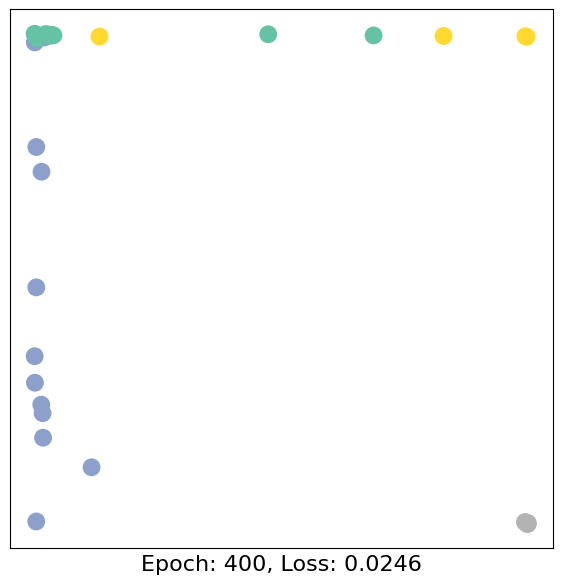

In [12]:
import time
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 430})'''))

model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h

for epoch in range(401):
    loss, h = train(data)
    if epoch % 10 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3)

正如你所看到的，我的三层 GCN 模型成功地将社群进行了线性划分，并正确分类了大多数节点。




